In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("academic_data.csv")

print("Data loaded successfully.")
df

Data loaded successfully.


,subject,attendance_percentage,total_present,total_absent,quiz_marks,assignment_marks,mid_marks,final_marks
0,Information Security,82,23,5,8,9,21,0
1,Software Construction,74,20,7,7,8,19,0
2,Database Systems,68,17,8,6,7,16,0
3,Artificial Intelligence,91,29,3,9,10,24,0
4,Computer Networks,59,13,9,5,6,14,0


In [4]:
print("Rows and Columns:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic summary:")
df.describe()

Rows and Columns: (5, 8)

Missing values:
subject                  0
attendance_percentage    0
total_present            0
total_absent             0
quiz_marks               0
assignment_marks         0
mid_marks                0
final_marks              0
dtype: int64

Basic summary:


,attendance_percentage,total_present,total_absent,quiz_marks,assignment_marks,mid_marks,final_marks
count,5.000000,5.0000,5.000000,5.000000,5.000000,5.000000,5.0
mean,74.800000,20.4000,6.400000,7.000000,8.000000,18.800000,0.0
std,12.357184,6.0663,2.408319,1.581139,1.581139,3.962323,0.0
min,59.000000,13.0000,3.000000,5.000000,6.000000,14.000000,0.0
25%,68.000000,17.0000,5.000000,6.000000,7.000000,16.000000,0.0
50%,74.000000,20.0000,7.000000,7.000000,8.000000,19.000000,0.0
75%,82.000000,23.0000,8.000000,8.000000,9.000000,21.000000,0.0
max,91.000000,29.0000,9.000000,9.000000,10.000000,24.000000,0.0


In [5]:
df["total_obtained_marks"] = (
    df["quiz_marks"] +
    df["assignment_marks"] +
    df["mid_marks"] +
    df["final_marks"]
)

df["current_marks_percentage"] = (df["total_obtained_marks"] / 100) * 100

df

,subject,attendance_percentage,total_present,total_absent,quiz_marks,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage
0,Information Security,82,23,5,8,9,21,0,38,38.0
1,Software Construction,74,20,7,7,8,19,0,34,34.0
2,Database Systems,68,17,8,6,7,16,0,29,29.0
3,Artificial Intelligence,91,29,3,9,10,24,0,43,43.0
4,Computer Networks,59,13,9,5,6,14,0,25,25.0


In [6]:
def calculate_risk(row):
    risk = 0

    if row["attendance_percentage"] < 75:
        risk += 40
    elif row["attendance_percentage"] < 80:
        risk += 20

    if row["current_marks_percentage"] < 50:
        risk += 35
    elif row["current_marks_percentage"] < 65:
        risk += 20

    if row["total_absent"] >= 8:
        risk += 15
    elif row["total_absent"] >= 5:
        risk += 8

    if row["mid_marks"] < 15:
        risk += 15
    elif row["mid_marks"] < 20:
        risk += 8

    return risk


df["risk_score"] = df.apply(calculate_risk, axis=1)

df

,subject,attendance_percentage,total_present,total_absent,quiz_marks,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage,risk_score
0,Information Security,82,23,5,8,9,21,0,38,38.0,43
1,Software Construction,74,20,7,7,8,19,0,34,34.0,91
2,Database Systems,68,17,8,6,7,16,0,29,29.0,98
3,Artificial Intelligence,91,29,3,9,10,24,0,43,43.0,35
4,Computer Networks,59,13,9,5,6,14,0,25,25.0,105


In [7]:
def risk_label(score):
    if score >= 60:
        return "High Risk"
    elif score >= 30:
        return "Warning"
    else:
        return "Safe"


df["risk_status"] = df["risk_score"].apply(risk_label)

df

,subject,attendance_percentage,total_present,total_absent,quiz_marks,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage,risk_score,risk_status
0,Information Security,82,23,5,8,9,21,0,38,38.0,43,Warning
1,Software Construction,74,20,7,7,8,19,0,34,34.0,91,High Risk
2,Database Systems,68,17,8,6,7,16,0,29,29.0,98,High Risk
3,Artificial Intelligence,91,29,3,9,10,24,0,43,43.0,35,Warning
4,Computer Networks,59,13,9,5,6,14,0,25,25.0,105,High Risk


In [8]:
dashboard = df[
    [
        "subject",
        "attendance_percentage",
        "total_present",
        "total_absent",
        "total_obtained_marks",
        "risk_score",
        "risk_status"
    ]
]

dashboard

,subject,attendance_percentage,total_present,total_absent,total_obtained_marks,risk_score,risk_status
0,Information Security,82,23,5,38,43,Warning
1,Software Construction,74,20,7,34,91,High Risk
2,Database Systems,68,17,8,29,98,High Risk
3,Artificial Intelligence,91,29,3,43,35,Warning
4,Computer Networks,59,13,9,25,105,High Risk


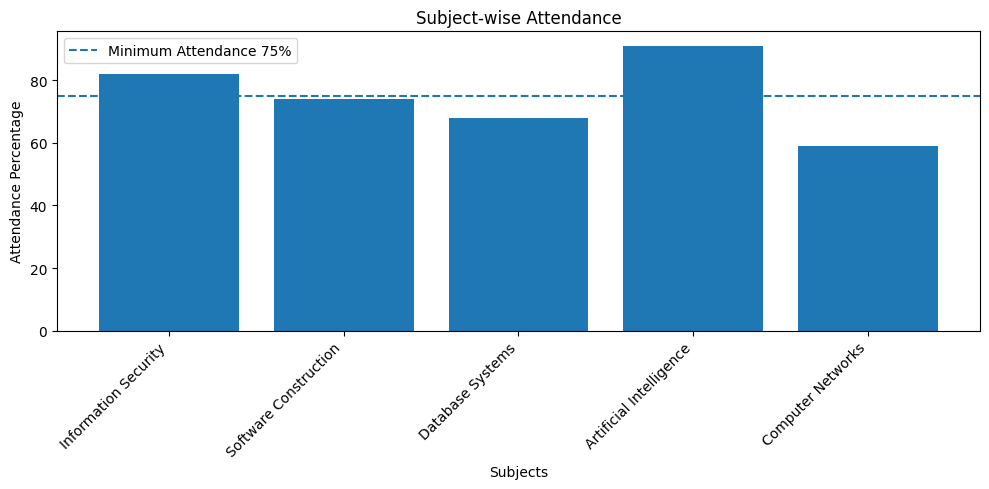

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(df["subject"], df["attendance_percentage"])

plt.axhline(y=75, linestyle="--", label="Minimum Attendance 75%")

plt.title("Subject-wise Attendance")
plt.xlabel("Subjects")
plt.ylabel("Attendance Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

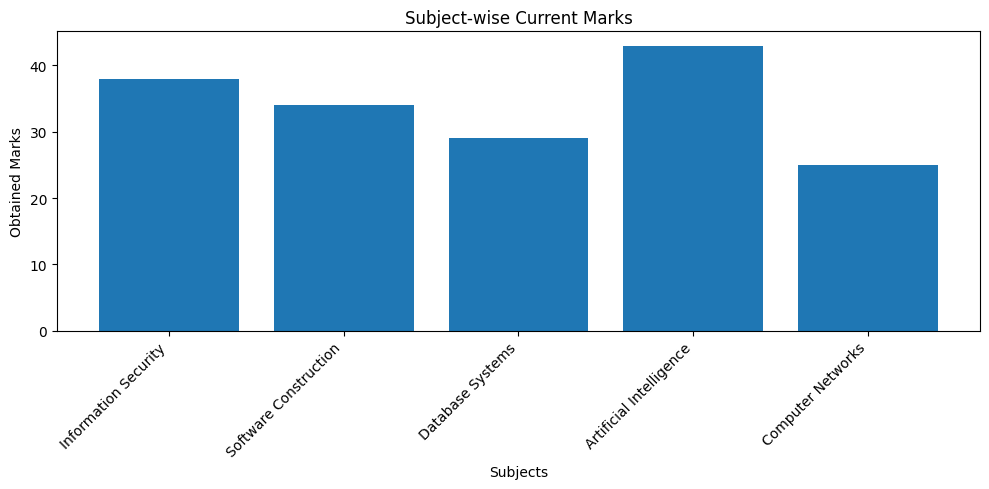

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(df["subject"], df["total_obtained_marks"])

plt.title("Subject-wise Current Marks")
plt.xlabel("Subjects")
plt.ylabel("Obtained Marks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

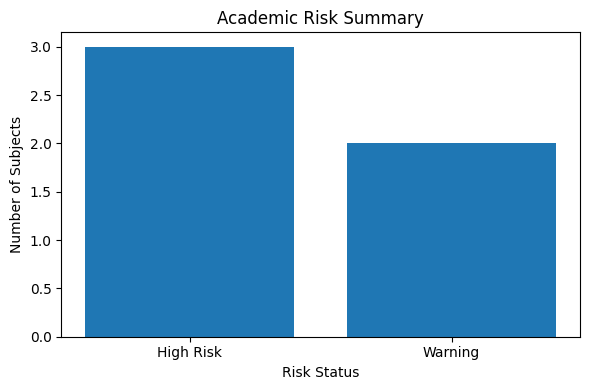

In [11]:
risk_counts = df["risk_status"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Academic Risk Summary")
plt.xlabel("Risk Status")
plt.ylabel("Number of Subjects")
plt.tight_layout()
plt.show()

In [12]:
def generate_recommendation(row):
    recommendations = []

    if row["attendance_percentage"] < 75:
        recommendations.append("Attendance is below 75%. Attend every upcoming class.")
    elif row["attendance_percentage"] < 80:
        recommendations.append("Attendance is close to danger zone. Avoid absents.")

    if row["current_marks_percentage"] < 50:
        recommendations.append("Marks are weak. Focus strongly on quizzes, assignments, and final preparation.")
    elif row["current_marks_percentage"] < 65:
        recommendations.append("Marks are average. Improve before finals.")

    if row["mid_marks"] < 15:
        recommendations.append("Mid marks are low. Revise weak topics before final exam.")

    if row["total_absent"] >= 8:
        recommendations.append("Too many absents. Attendance risk is serious.")

    if not recommendations:
        recommendations.append("Subject looks stable. Maintain performance.")

    return " ".join(recommendations)


df["recommendation"] = df.apply(generate_recommendation, axis=1)

df[["subject", "risk_status", "recommendation"]]

,subject,risk_status,recommendation
0,Information Security,Warning,"Marks are weak. Focus strongly on quizzes, ass..."
1,Software Construction,High Risk,Attendance is below 75%. Attend every upcoming...
2,Database Systems,High Risk,Attendance is below 75%. Attend every upcoming...
3,Artificial Intelligence,Warning,"Marks are weak. Focus strongly on quizzes, ass..."
4,Computer Networks,High Risk,Attendance is below 75%. Attend every upcoming...


In [13]:
df.to_csv("final_academic_dashboard.csv", index=False)

print("Final dashboard saved as final_academic_dashboard.csv")

Final dashboard saved as final_academic_dashboard.csv


In [14]:
readme = """
# SZABIST Academic Performance Dashboard

## Project Overview
This Jupyter Notebook project analyzes student academic performance using attendance, absents, quiz marks, assignment marks, mid marks, and final marks.

## Main Features
- Subject-wise academic tracking
- Attendance risk detection
- Marks-based performance analysis
- Risk score calculation
- Safe, Warning, and High Risk labels
- Subject-wise recommendations
- Charts for attendance, marks, and risk summary

## Files Included
- SZABIST_Academic_Dashboard.ipynb
- academic_data.csv
- final_academic_dashboard.csv
- README.md

## Technologies Used
- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib

## Future Upgrade
The next version can use browser automation with Playwright to extract attendance and marks directly from the university portal after login.

## Disclaimer
This project is for personal academic analysis only. Do not upload private login credentials, scraped private data, or sensitive student information to GitHub.
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme)

print("README.md created successfully.")

README.md created successfully.


In [15]:
df = pd.read_csv("final_scraped_academic_dashboard.csv")
df

,subject,instructor,program,section,total_lectures,total_present,total_absent,total_late,attendance_percentage,attendance_risk,...,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage,grade,reason,marks_risk,final_risk_status,recommendation
0,Artificial Intelligence,Muhammad Qasim,BSSE-6,A,22,12,10,0,54.55,High Risk,...,5.0,18.5,0.0,33.00,33.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
1,Formal Methods in Software Engineering,Arfa Asaf,BSSE-6,A,29,20,9,0,68.97,High Risk,...,5.4,26.0,0.0,43.65,44.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
2,Information Security,Safi Ullah -,BSSE-6,A,28,26,2,0,92.86,Safe,...,5.0,24.0,0.0,42.50,43.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
3,Lab: Software Construction and Development,Jawad Naseer -,BSSE-5,A,13,10,3,0,76.92,Warning,...,0.0,28.0,0.0,50.00,50.0,-,NaN,Warning,Warning,Attendance is close to danger zone. Avoid abse...
4,Professional Practices,Naveed Ahmad,BSSE-6,A,29,24,5,0,82.76,Safe,...,2.5,19.0,0.0,24.50,25.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
5,Software Construction and Development,Tooba Abdul Qudoos Khan,BSSE-5,A,15,11,3,1,80.00,Safe,...,9.0,24.0,0.0,44.00,44.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
6,Teachings of Holy Quran,Dr. Hafiz Javed Ahmad,BSSE-6,A,14,7,7,0,50.00,High Risk,...,0.0,0.0,0.0,0.00,0.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
7,Web Engineering,Muhammad Abuzar Chandia,BSSE-6,A,14,14,0,0,100.00,Safe,...,2.5,20.0,0.0,25.50,26.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...


In [18]:
import pandas as pd

df = pd.read_csv("data/processed/final_scraped_academic_dashboard.csv")
df

,subject,instructor,program,section,total_lectures,total_present,total_absent,total_late,attendance_percentage,attendance_risk,...,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage,grade,reason,marks_risk,final_risk_status,recommendation
0,Artificial Intelligence,Muhammad Qasim,BSSE-6,A,22,12,10,0,54.55,High Risk,...,5.0,18.5,0.0,33.00,33.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
1,Formal Methods in Software Engineering,Arfa Asaf,BSSE-6,A,29,20,9,0,68.97,High Risk,...,5.4,26.0,0.0,43.65,44.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
2,Information Security,Safi Ullah -,BSSE-6,A,28,26,2,0,92.86,Safe,...,5.0,24.0,0.0,42.50,43.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
3,Lab: Software Construction and Development,Jawad Naseer -,BSSE-5,A,13,10,3,0,76.92,Warning,...,0.0,28.0,0.0,50.00,50.0,-,NaN,Warning,Warning,Attendance is close to danger zone. Avoid abse...
4,Professional Practices,Naveed Ahmad,BSSE-6,A,29,24,5,0,82.76,Safe,...,2.5,19.0,0.0,24.50,25.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
5,Software Construction and Development,Tooba Abdul Qudoos Khan,BSSE-5,A,15,11,3,1,80.00,Safe,...,9.0,24.0,0.0,44.00,44.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
6,Teachings of Holy Quran,Dr. Hafiz Javed Ahmad,BSSE-6,A,14,7,7,0,50.00,High Risk,...,0.0,0.0,0.0,0.00,0.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
7,Web Engineering,Muhammad Abuzar Chandia,BSSE-6,A,14,14,0,0,100.00,Safe,...,2.5,20.0,0.0,25.50,26.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...


In [19]:
!pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = "data/processed/final_scraped_academic_dashboard.csv"

df = pd.read_csv(DATA_PATH)

print("GradeScope data loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

GradeScope data loaded successfully.
Rows: 8
Columns: 21


,subject,instructor,program,section,total_lectures,total_present,total_absent,total_late,attendance_percentage,attendance_risk,...,assignment_marks,mid_marks,final_marks,total_obtained_marks,current_marks_percentage,grade,reason,marks_risk,final_risk_status,recommendation
0,Artificial Intelligence,Muhammad Qasim,BSSE-6,A,22,12,10,0,54.55,High Risk,...,5.0,18.5,0.0,33.00,33.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
1,Formal Methods in Software Engineering,Arfa Asaf,BSSE-6,A,29,20,9,0,68.97,High Risk,...,5.4,26.0,0.0,43.65,44.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...
2,Information Security,Safi Ullah -,BSSE-6,A,28,26,2,0,92.86,Safe,...,5.0,24.0,0.0,42.50,43.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...
3,Lab: Software Construction and Development,Jawad Naseer -,BSSE-5,A,13,10,3,0,76.92,Warning,...,0.0,28.0,0.0,50.00,50.0,-,NaN,Warning,Warning,Attendance is close to danger zone. Avoid abse...
4,Professional Practices,Naveed Ahmad,BSSE-6,A,29,24,5,0,82.76,Safe,...,2.5,19.0,0.0,24.50,25.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...


In [21]:
df = df.copy()

numeric_columns = [
    "attendance_percentage",
    "total_present",
    "total_absent",
    "total_late",
    "quiz_marks",
    "assignment_marks",
    "mid_marks",
    "final_marks",
    "total_obtained_marks",
    "current_marks_percentage"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["subject_short"] = df["subject"].str.replace("Software Construction and Development", "SCD", regex=False)
df["subject_short"] = df["subject_short"].str.replace("Formal Methods in Software Engineering", "Formal Methods", regex=False)
df["subject_short"] = df["subject_short"].str.replace("Artificial Intelligence", "AI", regex=False)
df["subject_short"] = df["subject_short"].str.replace("Information Security", "InfoSec", regex=False)

df["attendance_gap"] = df["attendance_percentage"] - 75
df["marks_gap"] = df["current_marks_percentage"] - 50

df.head()

,subject,instructor,program,section,total_lectures,total_present,total_absent,total_late,attendance_percentage,attendance_risk,...,total_obtained_marks,current_marks_percentage,grade,reason,marks_risk,final_risk_status,recommendation,subject_short,attendance_gap,marks_gap
0,Artificial Intelligence,Muhammad Qasim,BSSE-6,A,22,12,10,0,54.55,High Risk,...,33.00,33.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...,AI,-20.45,-17.0
1,Formal Methods in Software Engineering,Arfa Asaf,BSSE-6,A,29,20,9,0,68.97,High Risk,...,43.65,44.0,F,Short Attendance,High Risk,High Risk,Attendance is below 75%. Attend every upcoming...,Formal Methods,-6.03,-6.0
2,Information Security,Safi Ullah -,BSSE-6,A,28,26,2,0,92.86,Safe,...,42.50,43.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...,InfoSec,17.86,-7.0
3,Lab: Software Construction and Development,Jawad Naseer -,BSSE-5,A,13,10,3,0,76.92,Warning,...,50.00,50.0,-,NaN,Warning,Warning,Attendance is close to danger zone. Avoid abse...,Lab: SCD,1.92,0.0
4,Professional Practices,Naveed Ahmad,BSSE-6,A,29,24,5,0,82.76,Safe,...,24.50,25.0,-,NaN,High Risk,High Risk,Marks are weak. Focus strongly before finals. ...,Professional Practices,7.76,-25.0


In [22]:
dashboard_columns = [
    "subject",
    "attendance_percentage",
    "total_present",
    "total_absent",
    "total_late",
    "quiz_marks",
    "assignment_marks",
    "mid_marks",
    "final_marks",
    "current_marks_percentage",
    "grade",
    "reason",
    "final_risk_status",
    "recommendation"
]

dashboard = df[dashboard_columns].copy()

dashboard = dashboard.sort_values(
    by=["final_risk_status", "attendance_percentage", "current_marks_percentage"],
    ascending=[True, True, True]
)

dashboard

,subject,attendance_percentage,total_present,total_absent,total_late,quiz_marks,assignment_marks,mid_marks,final_marks,current_marks_percentage,grade,reason,final_risk_status,recommendation
6,Teachings of Holy Quran,50.00,7,7,0,0.00,0.0,0.0,0.0,0.0,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
0,Artificial Intelligence,54.55,12,10,0,9.50,5.0,18.5,0.0,33.0,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
1,Formal Methods in Software Engineering,68.97,20,9,0,12.25,5.4,26.0,0.0,44.0,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
5,Software Construction and Development,80.00,11,3,1,11.00,9.0,24.0,0.0,44.0,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
4,Professional Practices,82.76,24,5,0,3.00,2.5,19.0,0.0,25.0,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
2,Information Security,92.86,26,2,0,13.50,5.0,24.0,0.0,43.0,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
7,Web Engineering,100.00,14,0,0,3.00,2.5,20.0,0.0,26.0,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
3,Lab: Software Construction and Development,76.92,10,3,0,0.00,0.0,28.0,0.0,50.0,-,NaN,Warning,Attendance is close to danger zone. Avoid abse...


In [23]:
total_subjects = len(df)
high_risk = (df["final_risk_status"] == "High Risk").sum()
warning = (df["final_risk_status"] == "Warning").sum()
safe = (df["final_risk_status"] == "Safe").sum()
avg_attendance = round(df["attendance_percentage"].mean(), 2)
avg_marks = round(df["current_marks_percentage"].mean(), 2)

summary = pd.DataFrame({
    "Metric": [
        "Total Subjects",
        "High Risk Subjects",
        "Warning Subjects",
        "Safe Subjects",
        "Average Attendance",
        "Average Marks"
    ],
    "Value": [
        total_subjects,
        high_risk,
        warning,
        safe,
        f"{avg_attendance}%",
        f"{avg_marks}%"
    ]
})

summary

,Metric,Value
0,Total Subjects,8
1,High Risk Subjects,7
2,Warning Subjects,1
3,Safe Subjects,0
4,Average Attendance,75.76%
5,Average Marks,33.12%


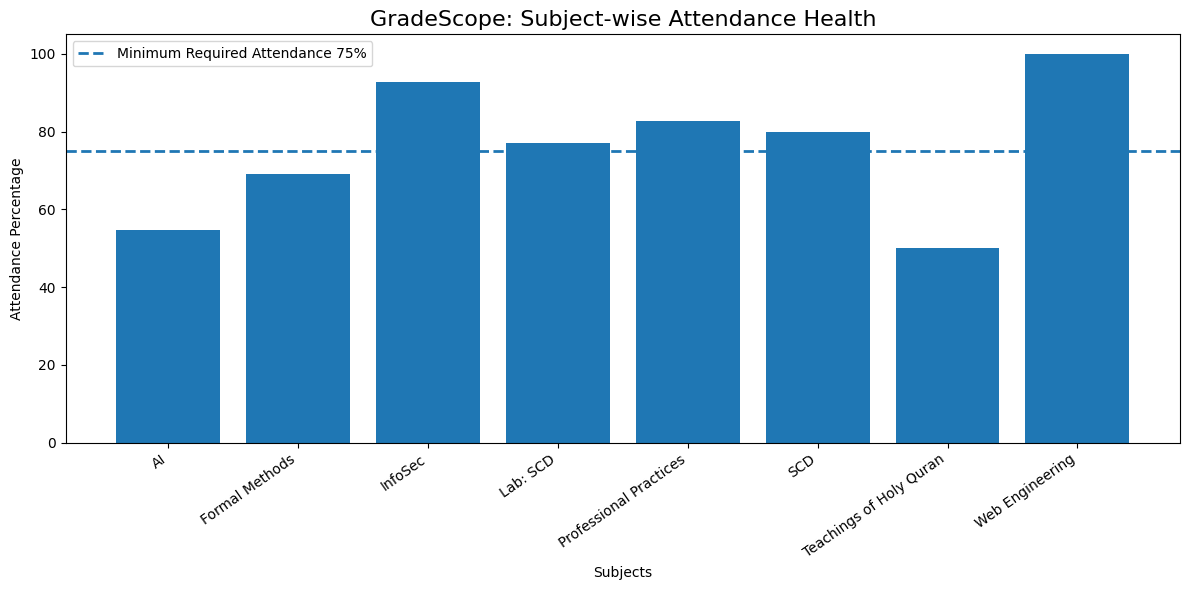

In [24]:
plt.figure(figsize=(12, 6))
plt.bar(df["subject_short"], df["attendance_percentage"])

plt.axhline(75, linestyle="--", linewidth=2, label="Minimum Required Attendance 75%")

plt.title("GradeScope: Subject-wise Attendance Health", fontsize=16)
plt.xlabel("Subjects")
plt.ylabel("Attendance Percentage")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()

Path("assets/charts").mkdir(parents=True, exist_ok=True)
plt.savefig("assets/charts/attendance_health.png", dpi=200, bbox_inches="tight")

plt.show()

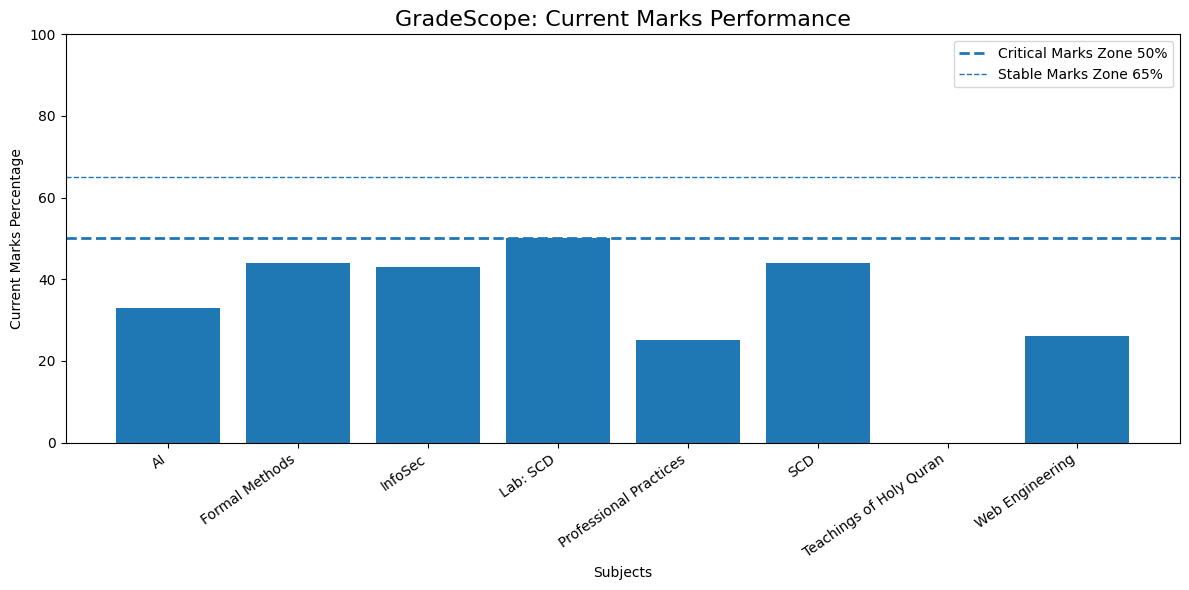

In [25]:
plt.figure(figsize=(12, 6))
plt.bar(df["subject_short"], df["current_marks_percentage"])

plt.axhline(50, linestyle="--", linewidth=2, label="Critical Marks Zone 50%")
plt.axhline(65, linestyle="--", linewidth=1, label="Stable Marks Zone 65%")

plt.title("GradeScope: Current Marks Performance", fontsize=16)
plt.xlabel("Subjects")
plt.ylabel("Current Marks Percentage")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.savefig("assets/charts/marks_performance.png", dpi=200, bbox_inches="tight")

plt.show()

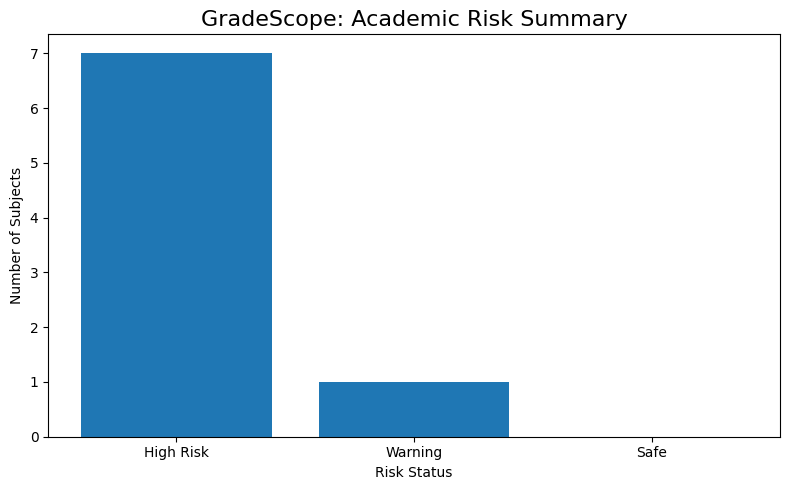

In [26]:
risk_order = ["High Risk", "Warning", "Safe"]
risk_counts = df["final_risk_status"].value_counts().reindex(risk_order).fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("GradeScope: Academic Risk Summary", fontsize=16)
plt.xlabel("Risk Status")
plt.ylabel("Number of Subjects")
plt.tight_layout()

plt.savefig("assets/charts/risk_summary.png", dpi=200, bbox_inches="tight")

plt.show()

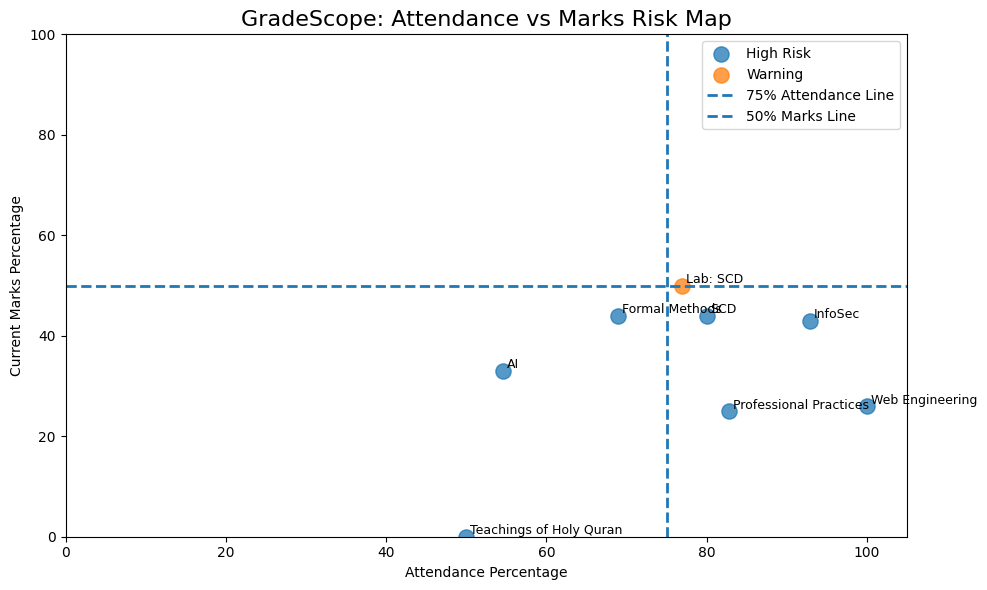

In [27]:
plt.figure(figsize=(10, 6))

for status in df["final_risk_status"].unique():
    subset = df[df["final_risk_status"] == status]
    plt.scatter(
        subset["attendance_percentage"],
        subset["current_marks_percentage"],
        s=120,
        alpha=0.75,
        label=status
    )

for _, row in df.iterrows():
    plt.text(
        row["attendance_percentage"] + 0.5,
        row["current_marks_percentage"] + 0.5,
        row["subject_short"],
        fontsize=9
    )

plt.axvline(75, linestyle="--", linewidth=2, label="75% Attendance Line")
plt.axhline(50, linestyle="--", linewidth=2, label="50% Marks Line")

plt.title("GradeScope: Attendance vs Marks Risk Map", fontsize=16)
plt.xlabel("Attendance Percentage")
plt.ylabel("Current Marks Percentage")
plt.xlim(0, 105)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.savefig("assets/charts/risk_map.png", dpi=200, bbox_inches="tight")

plt.show()

In [28]:
weakest_subjects = df.sort_values(
    by=["final_risk_status", "attendance_percentage", "current_marks_percentage"],
    ascending=[True, True, True]
)[[
    "subject",
    "attendance_percentage",
    "current_marks_percentage",
    "total_absent",
    "grade",
    "reason",
    "final_risk_status",
    "recommendation"
]]

weakest_subjects

,subject,attendance_percentage,current_marks_percentage,total_absent,grade,reason,final_risk_status,recommendation
6,Teachings of Holy Quran,50.00,0.0,7,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
0,Artificial Intelligence,54.55,33.0,10,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
1,Formal Methods in Software Engineering,68.97,44.0,9,F,Short Attendance,High Risk,Attendance is below 75%. Attend every upcoming...
5,Software Construction and Development,80.00,44.0,3,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
4,Professional Practices,82.76,25.0,5,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
2,Information Security,92.86,43.0,2,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
7,Web Engineering,100.00,26.0,0,-,NaN,High Risk,Marks are weak. Focus strongly before finals. ...
3,Lab: Software Construction and Development,76.92,50.0,3,-,NaN,Warning,Attendance is close to danger zone. Avoid abse...


In [29]:
demo_df = df.copy()

demo_df["student_name"] = "Demo Student"
demo_df["registration_number"] = "0000000"

demo_df.to_csv("data/processed/demo_gradescope_dashboard.csv", index=False)

print("Safe demo CSV created:")
print("data/processed/demo_gradescope_dashboard.csv")

Safe demo CSV created:
data/processed/demo_gradescope_dashboard.csv


In [32]:
from pathlib import Path

readme_lines = [
    "# GradeScope",
    "",
    "## Academic Risk Dashboard with Portal Automation",
    "",
    "GradeScope is a Jupyter Notebook based academic analytics project that extracts attendance and marks from a university student portal, converts raw portal pages into structured datasets, and builds a clean academic risk dashboard.",
    "",
    "## What It Does",
    "",
    "GradeScope helps answer one simple question:",
    "",
    "> Which subjects need urgent attention before it is too late?",
    "",
    "It analyzes:",
    "",
    "- Subject-wise attendance",
    "- Present, absent, and late counts",
    "- Quiz marks",
    "- Assignment marks",
    "- Midterm marks",
    "- Final marks",
    "- Total obtained marks",
    "- Grade status",
    "- Short attendance warnings",
    "- Academic risk level",
    "- Subject-wise recommendations",
    "",
    "## Why This Project Is Useful",
    "",
    "Most academic portals show raw data, but they do not explain risk clearly.",
    "",
    "GradeScope turns scattered academic portal information into a readable dashboard that highlights:",
    "",
    "- Subjects with dangerous attendance",
    "- Subjects with weak marks",
    "- Subjects affected by short attendance",
    "- Subjects that are safe",
    "- What action should be taken next",
    "",
    "## Dashboard Preview",
    "",
    "### Attendance Health",
    "",
    "![Attendance Health](assets/charts/attendance_health.png)",
    "",
    "### Marks Performance",
    "",
    "![Marks Performance](assets/charts/marks_performance.png)",
    "",
    "### Academic Risk Summary",
    "",
    "![Risk Summary](assets/charts/risk_summary.png)",
    "",
    "### Attendance vs Marks Risk Map",
    "",
    "![Risk Map](assets/charts/risk_map.png)",
    "",
    "## Tech Stack",
    "",
    "- Python",
    "- Jupyter Notebook",
    "- Pandas",
    "- BeautifulSoup",
    "- Playwright",
    "- Matplotlib",
    "",
    "## Project Structure",
    "",
    "```text",
    "gradescope/",
    "│",
    "├── README.md",
    "├── .gitignore",
    "├── SZABIST_Academic_Dashboard.ipynb",
    "├── scraper.ipynb",
    "│",
    "├── data/",
    "│   ├── raw/",
    "│   ├── processed/",
    "│   │   ├── final_scraped_academic_dashboard.csv",
    "│   │   └── demo_gradescope_dashboard.csv",
    "│   └── summaries/",
    "│",
    "├── scripts/",
    "│   ├── scraper.py",
    "│   ├── parse_attendance.py",
    "│   ├── parse_marks.py",
    "│   └── merge_dashboard.py",
    "│",
    "└── assets/",
    "    └── charts/",
    "        ├── attendance_health.png",
    "        ├── marks_performance.png",
    "        ├── risk_summary.png",
    "        └── risk_map.png",
    "```",
    "",
    "## Important Files",
    "",
    "| File | Purpose |",
    "|---|---|",
    "| `SZABIST_Academic_Dashboard.ipynb` | Main analysis and visualization notebook |",
    "| `scraper.ipynb` | Setup, scraping, parsing, and project management notebook |",
    "| `scripts/scraper.py` | Opens portal and captures attendance/result pages |",
    "| `scripts/parse_attendance.py` | Extracts attendance summary |",
    "| `scripts/parse_marks.py` | Extracts marks summary |",
    "| `scripts/merge_dashboard.py` | Merges attendance and marks into final dashboard CSV |",
    "| `data/processed/demo_gradescope_dashboard.csv` | Safe demo dataset for GitHub |",
    "",
    "## Main Output",
    "",
    "For private/local use:",
    "",
    "```text",
    "data/processed/final_scraped_academic_dashboard.csv",
    "```",
    "",
    "For GitHub/demo use:",
    "",
    "```text",
    "data/processed/demo_gradescope_dashboard.csv",
    "```",
    "",
    "## Privacy Notice",
    "",
    "This project is designed for personal academic analytics.",
    "",
    "Do not upload:",
    "",
    "- `.env`",
    "- Real portal HTML captures",
    "- Portal screenshots with personal information",
    "- Raw scraped private data",
    "- Login credentials",
    "",
    "Use the demo CSV for public GitHub repositories.",
    "",
    "## Future Improvements",
    "",
    "- Streamlit web dashboard",
    "- Automatic weekly scraping",
    "- Email alerts for low attendance",
    "- PDF academic report generator",
    "- Grade prediction model",
    "- Calendar-based absence impact calculator",
    "",
    "## Status",
    "",
    "GradeScope is functional. It can scrape, parse, merge, and visualize academic performance data from captured portal pages.",
]

Path("README.md").write_text("\n".join(readme_lines), encoding="utf-8")

print("README.md updated successfully with chart images.")

README.md updated successfully with chart images.


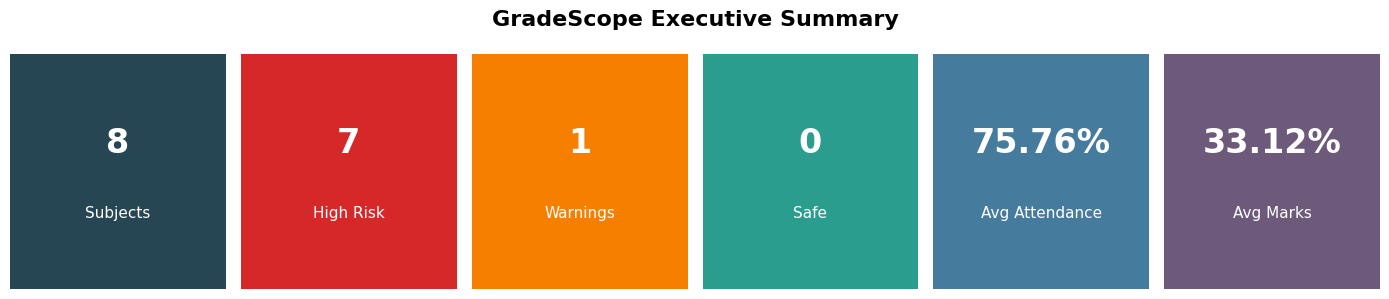

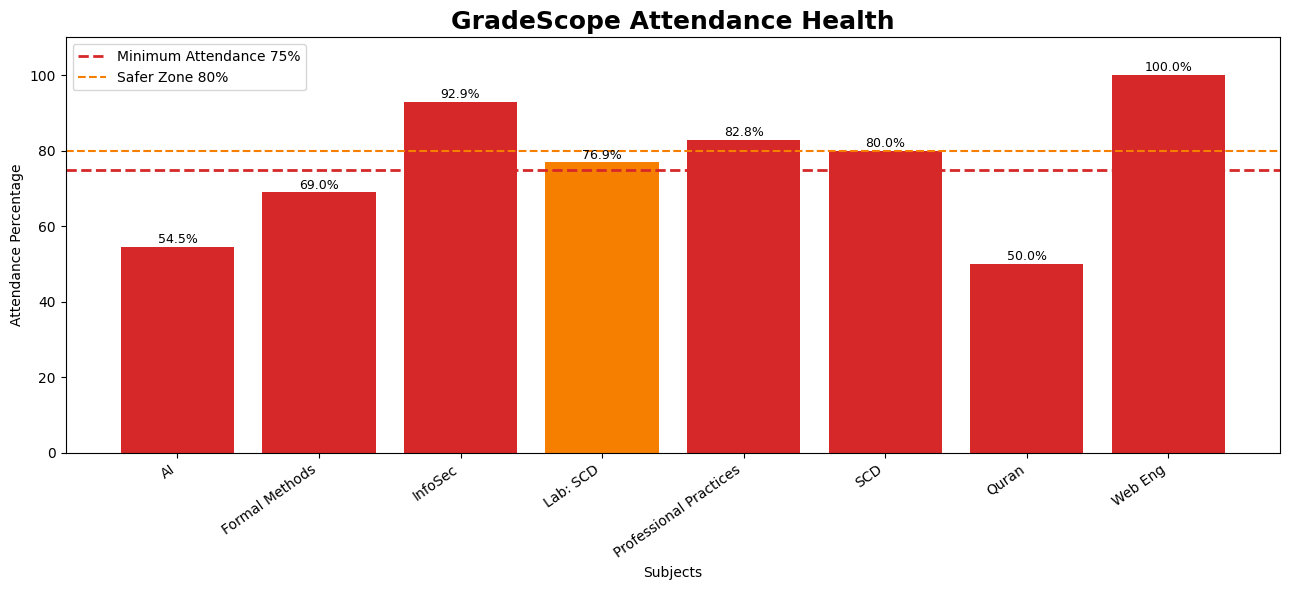

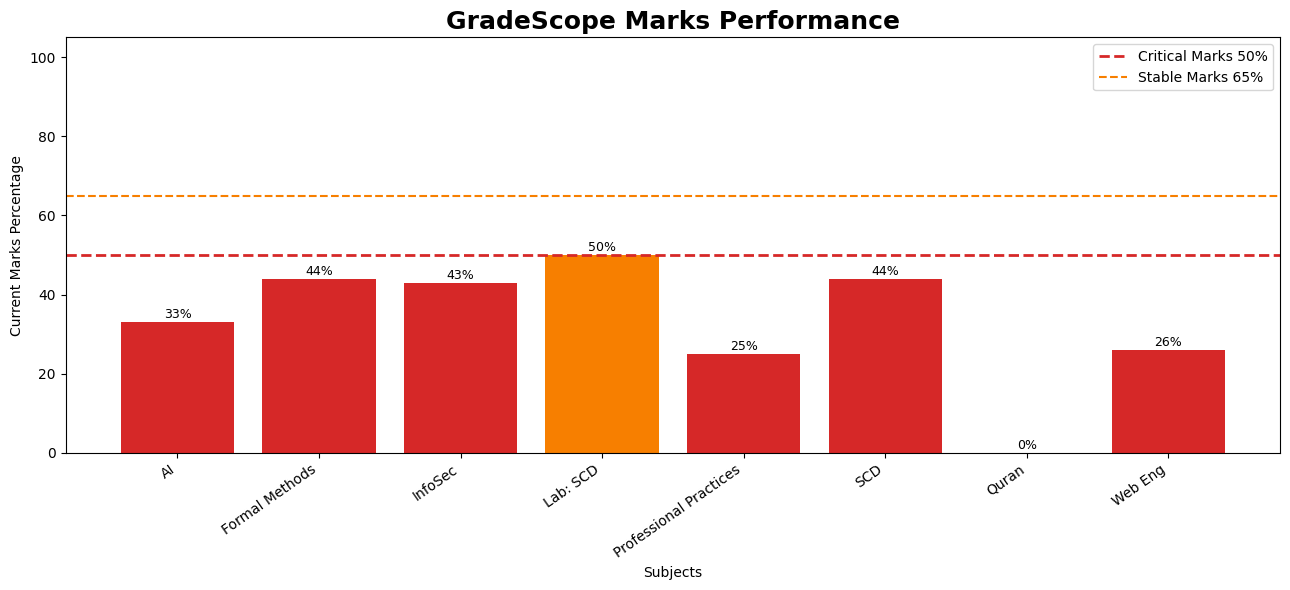

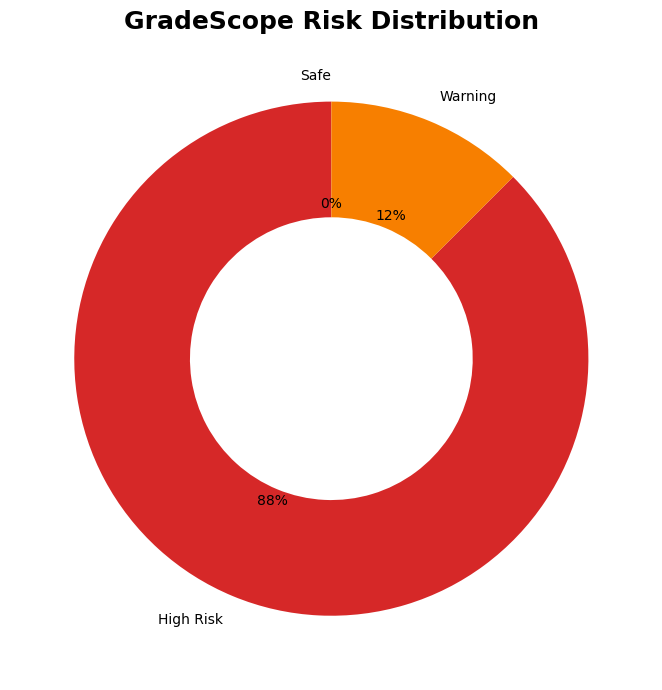

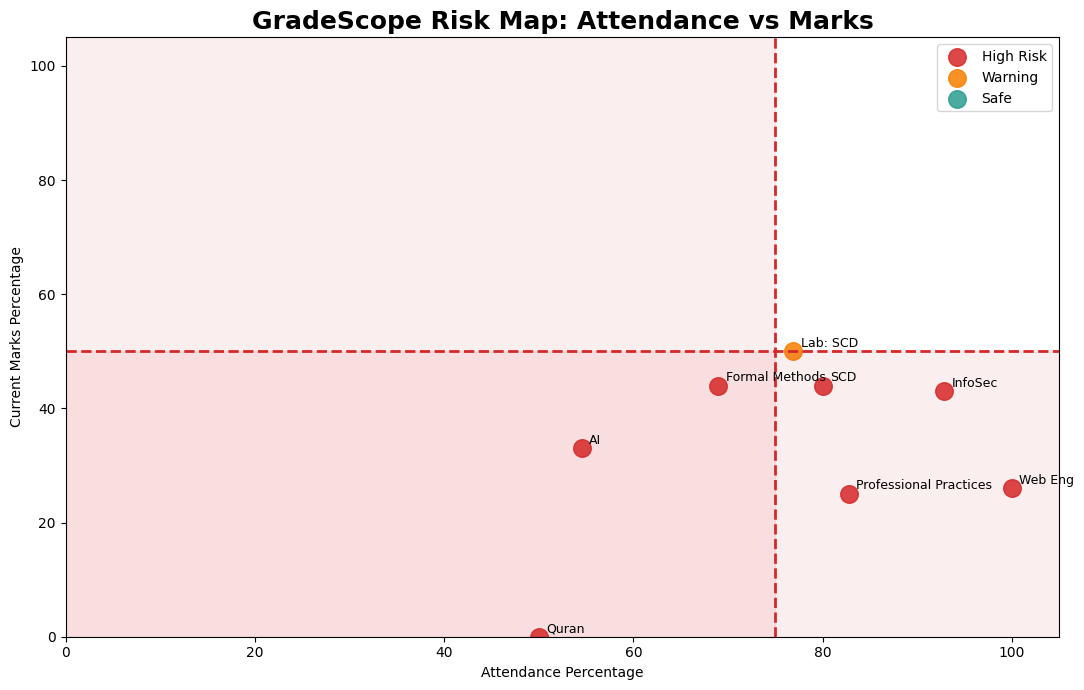

10/10 polish completed.
Created:
assets/charts/kpi_summary.png
assets/charts/attendance_health_pro.png
assets/charts/marks_performance_pro.png
assets/charts/risk_distribution_donut.png
assets/charts/risk_map_pro.png
data/processed/demo_gradescope_dashboard.csv
data/processed/gradescope_final_dashboard.csv


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()

DATA_PATH = ROOT / "data" / "processed" / "final_scraped_academic_dashboard.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError("Missing final_scraped_academic_dashboard.csv in data/processed/")

df = pd.read_csv(DATA_PATH)

# Create required folders
folders = [
    "assets/charts",
    "assets/reports",
    "data/processed",
    "docs"
]

for folder in folders:
    (ROOT / folder).mkdir(parents=True, exist_ok=True)

# Clean numeric columns
numeric_columns = [
    "attendance_percentage",
    "total_present",
    "total_absent",
    "total_late",
    "quiz_marks",
    "assignment_marks",
    "mid_marks",
    "final_marks",
    "total_obtained_marks",
    "current_marks_percentage"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Short subject labels
df["subject_short"] = df["subject"].astype(str)

short_names = {
    "Software Construction and Development": "SCD",
    "Lab: Software Construction and Development": "SCD Lab",
    "Formal Methods in Software Engineering": "Formal Methods",
    "Artificial Intelligence": "AI",
    "Information Security": "InfoSec",
    "Professional Practices": "Professional Practices",
    "Web Engineering": "Web Eng",
    "Teachings of Holy Quran": "Quran"
}

for full, short in short_names.items():
    df["subject_short"] = df["subject_short"].str.replace(full, short, regex=False)

# Risk color mapping
risk_colors = {
    "High Risk": "#d62828",
    "Warning": "#f77f00",
    "Safe": "#2a9d8f"
}

df["risk_color"] = df["final_risk_status"].map(risk_colors).fillna("#6c757d")

# Save sanitized demo dataset
demo_df = df.copy()

private_columns = [
    "student_name",
    "registration_number",
    "name",
    "reg_no",
    "reg_number"
]

for col in private_columns:
    if col in demo_df.columns:
        demo_df[col] = "Demo Student" if "name" in col.lower() else "0000000"

demo_df.to_csv(ROOT / "data" / "processed" / "demo_gradescope_dashboard.csv", index=False)

# Chart 1: KPI cards as image
total_subjects = len(df)
high_risk = int((df["final_risk_status"] == "High Risk").sum())
warning = int((df["final_risk_status"] == "Warning").sum())
safe = int((df["final_risk_status"] == "Safe").sum())
avg_attendance = round(df["attendance_percentage"].mean(), 2)
avg_marks = round(df["current_marks_percentage"].mean(), 2)

kpi_labels = [
    "Subjects",
    "High Risk",
    "Warnings",
    "Safe",
    "Avg Attendance",
    "Avg Marks"
]

kpi_values = [
    str(total_subjects),
    str(high_risk),
    str(warning),
    str(safe),
    f"{avg_attendance}%",
    f"{avg_marks}%"
]

kpi_bg = [
    "#264653",
    "#d62828",
    "#f77f00",
    "#2a9d8f",
    "#457b9d",
    "#6d597a"
]

plt.figure(figsize=(14, 3))
for i, (label, value, color) in enumerate(zip(kpi_labels, kpi_values, kpi_bg)):
    plt.subplot(1, 6, i + 1)
    plt.gca().set_facecolor(color)
    plt.text(0.5, 0.62, value, ha="center", va="center", fontsize=24, color="white", weight="bold")
    plt.text(0.5, 0.32, label, ha="center", va="center", fontsize=11, color="white")
    plt.xticks([])
    plt.yticks([])
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

plt.suptitle("GradeScope Executive Summary", fontsize=16, weight="bold")
plt.tight_layout()
plt.savefig(ROOT / "assets" / "charts" / "kpi_summary.png", dpi=220, bbox_inches="tight")
plt.show()

# Chart 2: Polished attendance chart
plt.figure(figsize=(13, 6))
bars = plt.bar(df["subject_short"], df["attendance_percentage"], color=df["risk_color"])

plt.axhline(75, linestyle="--", linewidth=2, color="#d62828", label="Minimum Attendance 75%")
plt.axhline(80, linestyle="--", linewidth=1.5, color="#f77f00", label="Safer Zone 80%")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

plt.title("GradeScope Attendance Health", fontsize=18, weight="bold")
plt.xlabel("Subjects")
plt.ylabel("Attendance Percentage")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "assets" / "charts" / "attendance_health_pro.png", dpi=220, bbox_inches="tight")
plt.show()

# Chart 3: Marks performance chart
plt.figure(figsize=(13, 6))
bars = plt.bar(df["subject_short"], df["current_marks_percentage"], color=df["risk_color"])

plt.axhline(50, linestyle="--", linewidth=2, color="#d62828", label="Critical Marks 50%")
plt.axhline(65, linestyle="--", linewidth=1.5, color="#f77f00", label="Stable Marks 65%")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.0f}%",
        ha="center",
        fontsize=9
    )

plt.title("GradeScope Marks Performance", fontsize=18, weight="bold")
plt.xlabel("Subjects")
plt.ylabel("Current Marks Percentage")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "assets" / "charts" / "marks_performance_pro.png", dpi=220, bbox_inches="tight")
plt.show()

# Chart 4: Risk distribution donut
risk_order = ["High Risk", "Warning", "Safe"]
risk_counts = df["final_risk_status"].value_counts().reindex(risk_order).fillna(0)
colors = [risk_colors[risk] for risk in risk_order]

plt.figure(figsize=(7, 7))
plt.pie(
    risk_counts,
    labels=risk_order,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.45}
)
plt.title("GradeScope Risk Distribution", fontsize=18, weight="bold")
plt.tight_layout()
plt.savefig(ROOT / "assets" / "charts" / "risk_distribution_donut.png", dpi=220, bbox_inches="tight")
plt.show()

# Chart 5: Attendance vs marks map
plt.figure(figsize=(11, 7))

for status in risk_order:
    subset = df[df["final_risk_status"] == status]
    plt.scatter(
        subset["attendance_percentage"],
        subset["current_marks_percentage"],
        s=160,
        color=risk_colors[status],
        alpha=0.85,
        label=status
    )

for _, row in df.iterrows():
    plt.text(
        row["attendance_percentage"] + 0.8,
        row["current_marks_percentage"] + 0.8,
        row["subject_short"],
        fontsize=9
    )

plt.axvline(75, linestyle="--", linewidth=2, color="#d62828")
plt.axhline(50, linestyle="--", linewidth=2, color="#d62828")
plt.axhspan(0, 50, alpha=0.08, color="#d62828")
plt.axvspan(0, 75, alpha=0.08, color="#d62828")

plt.title("GradeScope Risk Map: Attendance vs Marks", fontsize=18, weight="bold")
plt.xlabel("Attendance Percentage")
plt.ylabel("Current Marks Percentage")
plt.xlim(0, 105)
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "assets" / "charts" / "risk_map_pro.png", dpi=220, bbox_inches="tight")
plt.show()

# Final dashboard CSV
display_columns = [
    "subject",
    "attendance_percentage",
    "total_present",
    "total_absent",
    "total_late",
    "quiz_marks",
    "assignment_marks",
    "mid_marks",
    "final_marks",
    "current_marks_percentage",
    "grade",
    "reason",
    "final_risk_status",
    "recommendation"
]

final_display_df = df[[col for col in display_columns if col in df.columns]].copy()
final_display_df.to_csv(ROOT / "data" / "processed" / "gradescope_final_dashboard.csv", index=False)

print("10/10 polish completed.")
print("Created:")
print("assets/charts/kpi_summary.png")
print("assets/charts/attendance_health_pro.png")
print("assets/charts/marks_performance_pro.png")
print("assets/charts/risk_distribution_donut.png")
print("assets/charts/risk_map_pro.png")
print("data/processed/demo_gradescope_dashboard.csv")
print("data/processed/gradescope_final_dashboard.csv")

In [34]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()

df = pd.read_csv(ROOT / "data" / "processed" / "gradescope_final_dashboard.csv")

def risk_badge(status):
    if status == "High Risk":
        return '<span class="badge high">High Risk</span>'
    if status == "Warning":
        return '<span class="badge warning">Warning</span>'
    return '<span class="badge safe">Safe</span>'

table_rows = []

for _, row in df.iterrows():
    table_rows.append(
        "<tr>"
        f"<td>{row.get('subject', '')}</td>"
        f"<td>{row.get('attendance_percentage', 0):.2f}%</td>"
        f"<td>{int(row.get('total_present', 0))}</td>"
        f"<td>{int(row.get('total_absent', 0))}</td>"
        f"<td>{row.get('current_marks_percentage', 0):.0f}%</td>"
        f"<td>{row.get('grade', '-')}</td>"
        f"<td>{row.get('reason', '')}</td>"
        f"<td>{risk_badge(row.get('final_risk_status', 'Safe'))}</td>"
        f"<td>{row.get('recommendation', '')}</td>"
        "</tr>"
    )

html_lines = [
    "<!DOCTYPE html>",
    "<html>",
    "<head>",
    "<meta charset='UTF-8'>",
    "<title>GradeScope Academic Report</title>",
    "<style>",
    "body { font-family: Arial, sans-serif; margin: 0; background: #f5f7fb; color: #1f2937; }",
    ".container { max-width: 1200px; margin: auto; padding: 30px; }",
    ".hero { background: linear-gradient(135deg, #0f172a, #1e3a8a); color: white; padding: 35px; border-radius: 18px; margin-bottom: 25px; }",
    ".hero h1 { margin: 0; font-size: 42px; }",
    ".hero p { font-size: 18px; opacity: 0.9; }",
    ".grid { display: grid; grid-template-columns: repeat(2, 1fr); gap: 22px; margin-bottom: 30px; }",
    ".card { background: white; padding: 18px; border-radius: 16px; box-shadow: 0 8px 24px rgba(0,0,0,0.08); }",
    ".card img { width: 100%; border-radius: 10px; }",
    "table { width: 100%; border-collapse: collapse; background: white; border-radius: 16px; overflow: hidden; box-shadow: 0 8px 24px rgba(0,0,0,0.08); }",
    "th { background: #0f172a; color: white; padding: 12px; font-size: 13px; }",
    "td { padding: 11px; border-bottom: 1px solid #e5e7eb; font-size: 13px; vertical-align: top; }",
    ".badge { padding: 6px 10px; border-radius: 999px; color: white; font-weight: bold; font-size: 12px; display: inline-block; }",
    ".high { background: #d62828; }",
    ".warning { background: #f77f00; }",
    ".safe { background: #2a9d8f; }",
    ".section-title { font-size: 26px; margin-top: 35px; margin-bottom: 15px; }",
    "</style>",
    "</head>",
    "<body>",
    "<div class='container'>",
    "<div class='hero'>",
    "<h1>GradeScope</h1>",
    "<p>Academic Risk Dashboard with Portal Automation</p>",
    "</div>",
    "<div class='grid'>",
    "<div class='card'><img src='../charts/kpi_summary.png'></div>",
    "<div class='card'><img src='../charts/risk_distribution_donut.png'></div>",
    "<div class='card'><img src='../charts/attendance_health_pro.png'></div>",
    "<div class='card'><img src='../charts/marks_performance_pro.png'></div>",
    "<div class='card'><img src='../charts/risk_map_pro.png'></div>",
    "</div>",
    "<h2 class='section-title'>Subject Risk Table</h2>",
    "<table>",
    "<tr>",
    "<th>Subject</th>",
    "<th>Attendance</th>",
    "<th>Present</th>",
    "<th>Absent</th>",
    "<th>Marks</th>",
    "<th>Grade</th>",
    "<th>Reason</th>",
    "<th>Risk</th>",
    "<th>Recommendation</th>",
    "</tr>",
    *table_rows,
    "</table>",
    "</div>",
    "</body>",
    "</html>"
]

report_path = ROOT / "assets" / "reports" / "gradescope_report.html"
report_path.write_text("\n".join(html_lines), encoding="utf-8")

print("Professional HTML report created:")
print(report_path)

Professional HTML report created:
C:\Users\munee\szabist-academic-dashboard\assets\reports\gradescope_report.html


In [35]:
from pathlib import Path

ROOT = Path.cwd()

requirements_lines = [
    "pandas",
    "numpy",
    "matplotlib",
    "beautifulsoup4",
    "playwright",
    "python-dotenv"
]

(ROOT / "requirements.txt").write_text("\n".join(requirements_lines), encoding="utf-8")

data_dictionary_lines = [
    "# GradeScope Data Dictionary",
    "",
    "| Column | Meaning |",
    "|---|---|",
    "| subject | Course or subject name |",
    "| instructor | Course instructor name |",
    "| program | Program or semester group |",
    "| section | Class section |",
    "| total_lectures | Total lectures recorded |",
    "| total_present | Number of present lectures |",
    "| total_absent | Number of absent lectures |",
    "| total_late | Number of late lectures |",
    "| attendance_percentage | Calculated attendance percentage |",
    "| attendance_risk | Attendance-only risk label |",
    "| quiz_marks | Total quiz marks obtained |",
    "| assignment_marks | Total assignment marks obtained |",
    "| mid_marks | Midterm marks obtained |",
    "| final_marks | Final marks obtained |",
    "| total_obtained_marks | Total marks obtained out of 100 |",
    "| current_marks_percentage | Current marks percentage |",
    "| grade | Current portal grade |",
    "| reason | Portal reason, such as short attendance |",
    "| marks_risk | Marks-only risk label |",
    "| final_risk_status | Final combined risk label |",
    "| recommendation | Subject-wise action recommendation |",
]

(ROOT / "docs" / "DATA_DICTIONARY.md").write_text("\n".join(data_dictionary_lines), encoding="utf-8")

privacy_lines = [
    "# Privacy Checklist",
    "",
    "Before uploading to GitHub, verify that these are not uploaded:",
    "",
    "- `.env`",
    "- Real portal HTML captures",
    "- Portal screenshots",
    "- Real registration number",
    "- Real student name",
    "- Raw private academic files",
    "- Login credentials",
    "",
    "Use only:",
    "",
    "- `data/processed/demo_gradescope_dashboard.csv`",
    "- generated charts",
    "- scripts",
    "- notebooks",
    "- README",
]

(ROOT / "docs" / "PRIVACY_CHECKLIST.md").write_text("\n".join(privacy_lines), encoding="utf-8")

print("Created:")
print("requirements.txt")
print("docs/DATA_DICTIONARY.md")
print("docs/PRIVACY_CHECKLIST.md")

Created:
requirements.txt
docs/DATA_DICTIONARY.md
docs/PRIVACY_CHECKLIST.md


In [36]:
from pathlib import Path

ROOT = Path.cwd()

readme_lines = [
    "# GradeScope",
    "",
    "## Academic Risk Dashboard with Portal Automation",
    "",
    "GradeScope is a Python and Jupyter Notebook project that turns raw university portal data into a clean academic risk dashboard.",
    "",
    "It automates portal capture, parses attendance and marks from HTML pages, merges the extracted data, calculates academic risk, and generates visual insights with subject-wise recommendations.",
    "",
    "## Why GradeScope Exists",
    "",
    "Most student portals show data, but they do not explain risk clearly.",
    "",
    "GradeScope answers:",
    "",
    "> Which subjects need urgent attention before it is too late?",
    "",
    "## Core Features",
    "",
    "- Portal automation using Playwright",
    "- Attendance page capture",
    "- Marks page capture",
    "- HTML parsing using BeautifulSoup",
    "- Subject-wise attendance calculation",
    "- Present, absent, and late count extraction",
    "- Quiz, assignment, midterm, final, and total marks extraction",
    "- Grade and short-attendance reason extraction",
    "- Combined academic risk scoring",
    "- Subject-wise recommendations",
    "- Professional charts",
    "- HTML report generation",
    "- Demo dataset for public GitHub use",
    "- Privacy-safe project structure",
    "",
    "## Dashboard Preview",
    "",
    "### Executive Summary",
    "",
    "![KPI Summary](assets/charts/kpi_summary.png)",
    "",
    "### Attendance Health",
    "",
    "![Attendance Health](assets/charts/attendance_health_pro.png)",
    "",
    "### Marks Performance",
    "",
    "![Marks Performance](assets/charts/marks_performance_pro.png)",
    "",
    "### Risk Distribution",
    "",
    "![Risk Distribution](assets/charts/risk_distribution_donut.png)",
    "",
    "### Attendance vs Marks Risk Map",
    "",
    "![Risk Map](assets/charts/risk_map_pro.png)",
    "",
    "## Tech Stack",
    "",
    "- Python",
    "- Jupyter Notebook",
    "- Pandas",
    "- NumPy",
    "- Matplotlib",
    "- BeautifulSoup",
    "- Playwright",
    "",
    "## Project Structure",
    "",
    "```text",
    "gradescope/",
    "│",
    "├── README.md",
    "├── requirements.txt",
    "├── .gitignore",
    "├── SZABIST_Academic_Dashboard.ipynb",
    "├── scraper.ipynb",
    "│",
    "├── data/",
    "│   ├── raw/",
    "│   ├── processed/",
    "│   │   ├── demo_gradescope_dashboard.csv",
    "│   │   └── gradescope_final_dashboard.csv",
    "│   └── summaries/",
    "│",
    "├── scripts/",
    "│   ├── scraper.py",
    "│   ├── parse_attendance.py",
    "│   ├── parse_marks.py",
    "│   └── merge_dashboard.py",
    "│",
    "├── assets/",
    "│   ├── charts/",
    "│   └── reports/",
    "│",
    "└── docs/",
    "    ├── DATA_DICTIONARY.md",
    "    └── PRIVACY_CHECKLIST.md",
    "```",
    "",
    "## Main Outputs",
    "",
    "| Output | Purpose |",
    "|---|---|",
    "| `data/processed/demo_gradescope_dashboard.csv` | Public-safe demo dataset |",
    "| `data/processed/gradescope_final_dashboard.csv` | Final processed dashboard dataset |",
    "| `assets/reports/gradescope_report.html` | Professional HTML dashboard report |",
    "| `assets/charts/` | Generated visual dashboard charts |",
    "| `docs/DATA_DICTIONARY.md` | Explanation of dataset columns |",
    "| `docs/PRIVACY_CHECKLIST.md` | Safety checklist before uploading |",
    "",
    "## How to Run",
    "",
    "Install dependencies:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "python -m playwright install",
    "```",
    "",
    "Then open:",
    "",
    "```text",
    "SZABIST_Academic_Dashboard.ipynb",
    "```",
    "",
    "For scraping and parsing workflow, open:",
    "",
    "```text",
    "scraper.ipynb",
    "```",
    "",
    "## Privacy Notice",
    "",
    "This project is designed for personal academic analytics.",
    "",
    "Do not upload:",
    "",
    "- `.env`",
    "- Real portal captures",
    "- Portal screenshots with personal details",
    "- Raw private academic data",
    "- Login credentials",
    "",
    "Use the demo dataset for public GitHub repositories.",
    "",
    "## Future Improvements",
    "",
    "- Streamlit web dashboard",
    "- Weekly auto-refresh",
    "- Email alerts for low attendance",
    "- PDF report export",
    "- Grade prediction model",
    "- Absence impact calculator",
    "- Course-wise study priority planner",
    "",
    "## Status",
    "",
    "GradeScope is fully functional as an academic portal automation and analytics project.",
]

(ROOT / "README.md").write_text("\n".join(readme_lines), encoding="utf-8")

print("README.md upgraded to 10/10 version.")

README.md upgraded to 10/10 version.
